In [1]:
from matplotlib import pyplot as plt
from math import log2, ceil
import numpy as np
import matplotlib as mpl
import re
from matplotlib.ticker import AutoMinorLocator

In [2]:
def data_entry(solver):
    filename=f'../../out/edge/{solver}.compiled.txt'
    data = []
    f = open(filename, 'r')
    line = f.readline()
    match = re.search(r'^(?:sim_|)(k\d+)', line)
    kmer = match.group(1)
    for line in f:
        match = re.search(r'^(?:sim_|)(k\d+)', line)
        if match is None:
            data_match = re.search(r'^(\[\d+, \d+.?\d*\])', line)
            data.append(eval(data_match.group(1)))
        else:
            data = np.array(sorted(data, key=lambda e: e[0]))
            np.save(f'../../out/edge/data.{solver}.{kmer}', data)
            kmer = match.group(1)
            data = []
            
    data = np.array(sorted(data, key=lambda e: e[0]))
    np.save(f'../../out/edge/data.{solver}.{kmer}', data)

In [3]:
data_entry('mqlib')
data_entry('dwave')
data_entry('gurobi')

In [4]:
dwave_data_k101 = np.load('../../out/edge/data.dwave.k101.npy')
dwave_data_k201 = np.load('../../out/edge/data.dwave.k201.npy')
dwave_data_k301 = np.load('../../out/edge/data.dwave.k301.npy')
dwave_data_k501 = np.load('../../out/edge/data.dwave.k501.npy')

mqlib_data_k41 = np.load('../../out/edge/data.mqlib.k41.npy')
mqlib_data_k51 = np.load('../../out/edge/data.mqlib.k51.npy')
mqlib_data_k61 = np.load('../../out/edge/data.mqlib.k61.npy')
mqlib_data_k71 = np.load('../../out/edge/data.mqlib.k71.npy')
mqlib_data_k101 = np.load('../../out/edge/data.mqlib.k101.npy')
mqlib_data_k201 = np.load('../../out/edge/data.mqlib.k201.npy')
mqlib_data_k301 = np.load('../../out/edge/data.mqlib.k201.npy')

gurobi_data_k101 = np.load('../../out/edge/data.gurobi.k101.npy')
gurobi_data_k201 = np.load('../../out/edge/data.gurobi.k201.npy')
gurobi_data_k301 = np.load('../../out/edge/data.gurobi.k301.npy')

In [5]:
dwave_data_k301 = np.delete(dwave_data_k301, [0], 0)

In [6]:
times, counts = np.unique(mqlib_data_k51[:,0], return_counts=True)
print(times, counts)

[ 60 120 240 480 960] [5 5 5 5 5]


In [7]:
data, counts = np.unique(mqlib_data_k71, return_counts=True)
print(data, counts)

[  0   2  60  85 120 170 240] [31 19 10 10 10 10 10]


In [8]:
def compare_solvers(title: str, *args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']
    
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    names = ['D-Wave', 'Gurobi', 'MQLib']
    markers = ['o', 'x', 's', 'v']
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data, return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(unique_data[:, 0] / 60, unique_data[:, 1], s=marker_sizes, color=colours[idx], label=names[idx], alpha=0.5, marker=markers[idx])
    ax.set_title(title)    
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5))
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

In [9]:
def compare_problem_sizes(title: str, *args):
    fig, ax = plt.subplots()
    
    cmap = mpl.colormaps['magma_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.1, 0.9, len(args)))
    
    markers = ['o', 'x', 's', 'v']
    
    kmer_sizes = [arg[0] for arg in args]
    
    for idx, data in enumerate(args):
        unique_data, unique_counts = np.unique(data[1], return_counts=True, axis=0)
        # times, time_counts = np.unique(data[:, 0], return_counts=True)
        marker_sizes = np.zeros_like(unique_data[:, 0])
        for i in range(unique_counts.shape[0]):
            # marker_sizes[i] = 10 ** 2 * (unique_counts[i] / time_counts[np.argmax(times == unique_data[i, 0])])
            marker_sizes[i] = 5 ** 2 * (unique_counts[i])
        ax.scatter(
            np.round(unique_data[:, 0] / 60, 1), unique_data[:, 1], 
            s=marker_sizes, color=colours[idx], label=kmer_sizes[idx], alpha=0.5, marker=markers[idx]
        )
    ax.set_title(title)
    ax.set_xlabel(r'$T / 60$')
    ax.set_ylabel(r'Energy')
    ax.set_xscale('log', base=2)
    # ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), title='k')
    ax.grid(True, which="both")
    fig.tight_layout()
    plt.show()

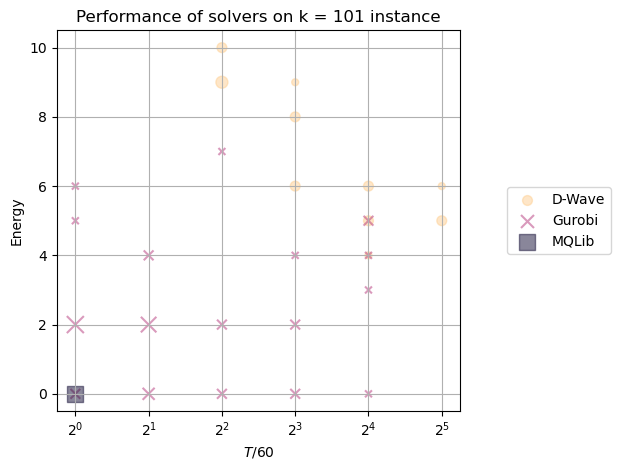

In [10]:
compare_solvers(
    'Performance of solvers on k = 101 instance',
    dwave_data_k101, gurobi_data_k101, mqlib_data_k101[0:5])

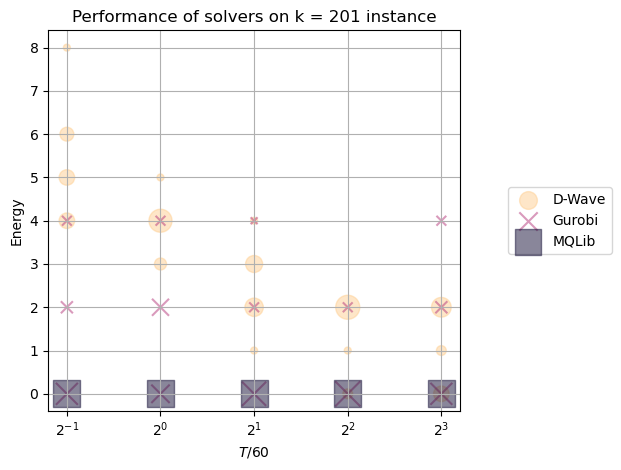

In [11]:
compare_solvers(
    'Performance of solvers on k = 201 instance',
    dwave_data_k201, 
    gurobi_data_k201, 
    mqlib_data_k201
)

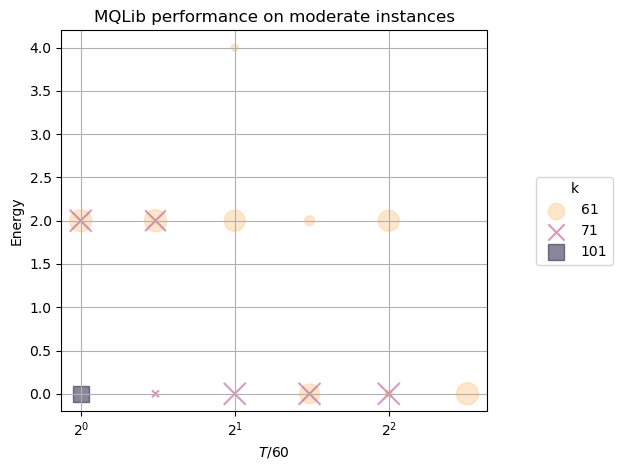

In [12]:
compare_problem_sizes(
    'MQLib performance on moderate instances',
    (61, mqlib_data_k61), 
    (71, mqlib_data_k71), 
    (101, mqlib_data_k101[0:5,:]),
)

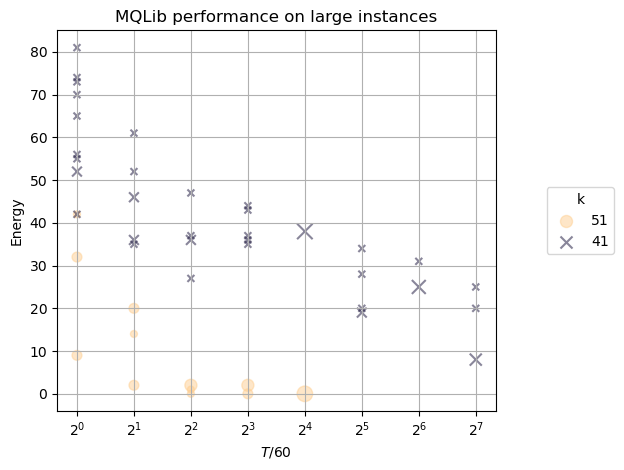

In [13]:
compare_problem_sizes(
    'MQLib performance on large instances',
    (51, mqlib_data_k51),
    (41, mqlib_data_k41)
)

In [14]:
def solver_histograms(title: str, data_tuple: tuple):
    all_times = set()
    for data in data_tuple:
        all_times = all_times.union(set(data[:, 0]))
    
    times_to_remove = set([85, 170])
    all_times.difference(times_to_remove)
    
    all_times = sorted(list(all_times))
    
    all_energies = set()
    for data in data_tuple:
        all_energies = all_energies.union(set(data[:, 1]))
    all_energies = sorted(list(all_energies))
    
    bins = np.arange(min(all_energies), max(all_energies) + 2)
    
    cmap = mpl.colormaps['RdYlGn_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.1, 0.9, len(data_tuple)))
    
    names = ['MQLib', 'Gurobi', 'D-Wave']
     
    fig, axs = plt.subplots(nrows=1, ncols=len(all_times), sharex=True)
    fig.subplots_adjust(left=-1, right=0)
    energy_max = int(max(all_energies))
    
    for idx, time in enumerate(all_times):
        energies = [data[data[:, 0] == time][:, 1] for data in data_tuple]
        ax = axs[idx]
        ax.hist(energies, bins, orientation='horizontal', align='left', rwidth=0.4)
        ax.set_xlabel(fr'$T = {int(time)}$')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.get_yaxis().set_ticks(range(0, energy_max + 1, ceil(energy_max / 10)))
        ax.get_xaxis().set_ticks([])
        if not idx == 0:
            ax.get_yaxis().set_ticklabels([])
            # ax.spines['left'].set_visible(False)
     
    axs[0].set_ylabel(r'Energy')
    fig.legend(names, loc='center left', bbox_to_anchor=(1., 0.5), title='k')
    fig.tight_layout()
    st = plt.suptitle(title)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.85)   
    plt.show()

In [15]:
dwave_data_k301[0:15,:]

array([[30.,  0.],
       [30.,  2.],
       [30.,  0.],
       [30.,  2.],
       [30.,  2.],
       [30.,  1.],
       [30.,  2.],
       [30.,  2.],
       [30.,  2.],
       [60.,  1.],
       [60.,  0.],
       [60.,  1.],
       [60.,  2.],
       [60.,  2.],
       [60.,  2.]])

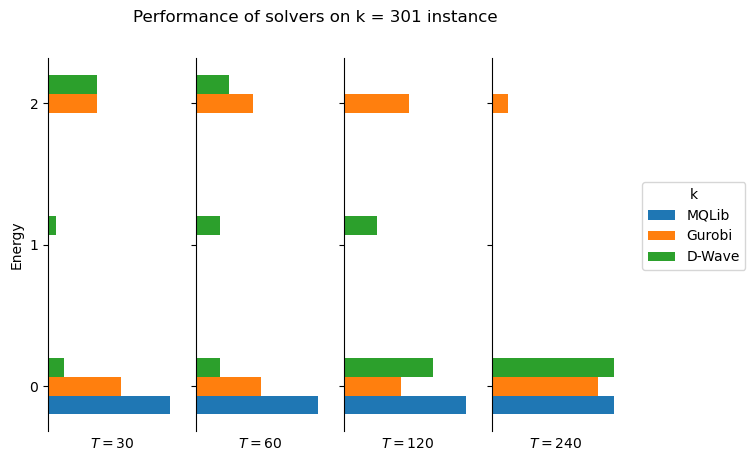

In [16]:
solver_histograms(
    'Performance of solvers on k = 301 instance', 
    (mqlib_data_k301[0:-15,:], gurobi_data_k301[0:-15,:], dwave_data_k301)
)

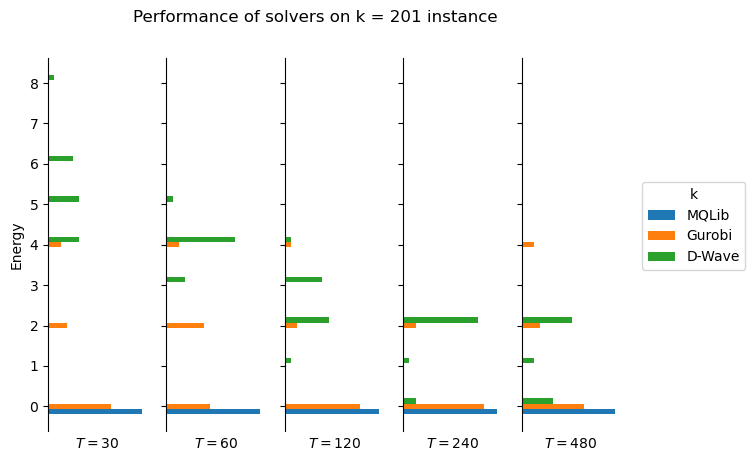

In [17]:
solver_histograms(
    'Performance of solvers on k = 201 instance', 
    (mqlib_data_k201, gurobi_data_k201, dwave_data_k201)
)

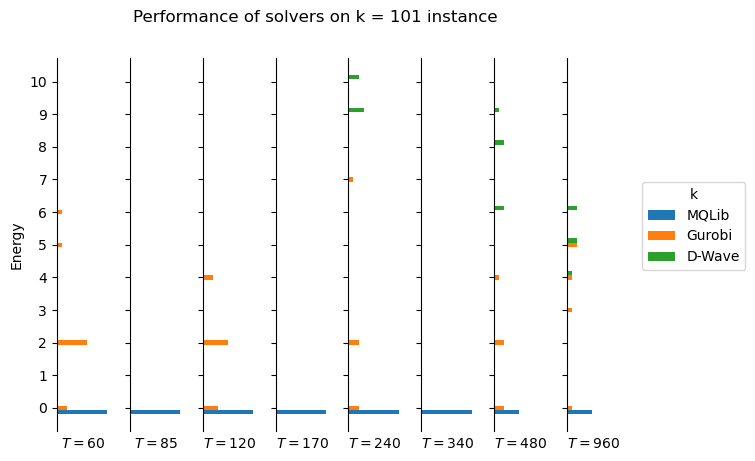

In [18]:
solver_histograms(
    'Performance of solvers on k = 101 instance', 
    (mqlib_data_k101, gurobi_data_k101, dwave_data_k101[0:-3])
)

In [19]:
def instance_histograms(title: str, data_tuple: tuple):
    all_times = set()
    for data in data_tuple:
        all_times = all_times.union(set(data[1][:, 0]))
    all_times = sorted(list(all_times))
    
    all_energies = set()
    for data in data_tuple:
        all_energies = all_energies.union(set(data[1][:, 1]))
    all_energies = sorted(list(all_energies))
    energy_max = int(max(all_energies))
    
    bins = np.arange(0, energy_max + 2, ceil((energy_max + 2)/20))
    
    cmap = mpl.colormaps['RdYlGn_r']

    # Take colors at regular intervals spanning the colormap.
    colours = cmap(np.linspace(0.05, 0.85, len(data_tuple)))
    
    kmer_sizes = [data[0] for data in data_tuple]

    fig, axs = plt.subplots(nrows=1, ncols=len(all_times), sharex=True)
    fig.subplots_adjust(left=-1, right=0)
    
    for idx, time in enumerate(all_times):
        energies = [data[1][data[1][:, 0] == time][:, 1] for data in data_tuple]
        # print(time)
        # for energy in energies:
        #     print(energy.shape[0])
        ax = axs[idx]
        ax.hist(energies, bins, orientation='horizontal', align='left', rwidth=0.4, color=colours)
        ax.set_xlabel(fr'$T = {int(time)}$')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.get_yaxis().set_ticks(range(0, energy_max + 1, ceil(energy_max / 10)))
        ax.get_xaxis().set_ticks([])
        if not idx == 0:
            ax.get_yaxis().set_ticklabels([])
            # ax.spines['left'].set_visible(False)
     
    axs[0].set_ylabel(r'Energy')
    fig.legend(kmer_sizes, loc='center left', bbox_to_anchor=(1., 0.5), title='k')
    fig.tight_layout()
    st = plt.suptitle(title)
    st.set_y(0.95)
    fig.subplots_adjust(top=0.85)   
    plt.show()

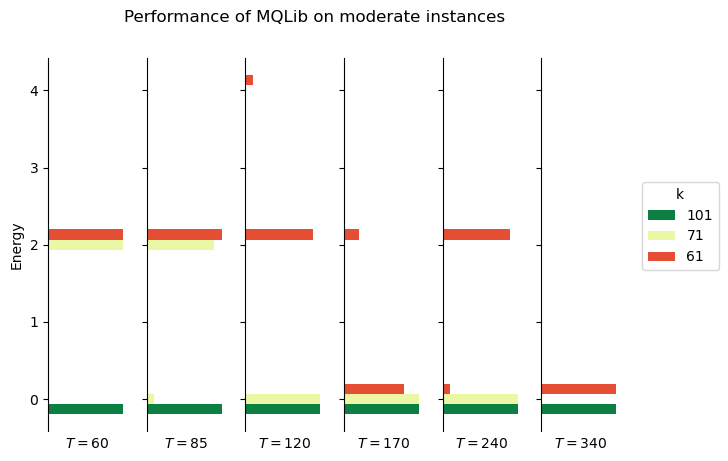

In [20]:
instance_histograms(
    'Performance of MQLib on moderate instances', 
    ((101, mqlib_data_k101[:-10,:]), (71, mqlib_data_k71), (61, mqlib_data_k61))
)

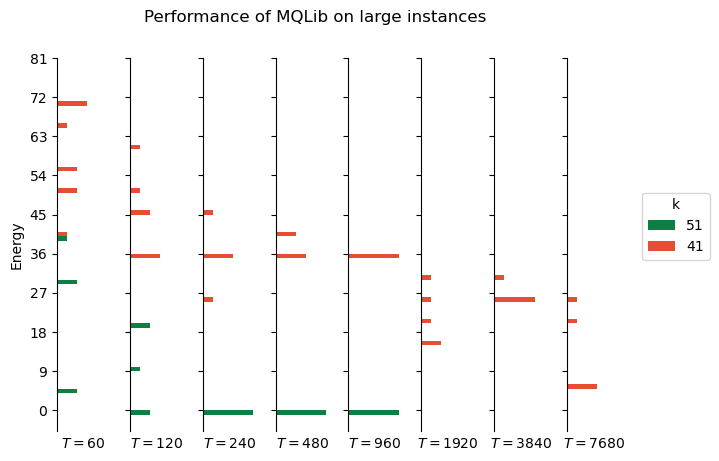

In [21]:
instance_histograms(
    'Performance of MQLib on large instances', 
    ((51, mqlib_data_k51), (41, mqlib_data_k41))
)